# Проект A/B‑тестирование для интернет‑магазина «Фитнес‑мания»

In [ ]:
## 0. Подготовка окружения и загрузка данных



## 1. Приоритизация гипотез (ICE и RICE)

- Представьте таблицу гипотез
- Рассчитайте ICE и RICE
- Отсортируйте гипотезы по убыванию приоритетов

**Вывод:** Укажите, какие гипотезы оказались наиболее приоритетными и почему

## Задание 1. Приоритизация гипотез (ICE и RICE)

### Подход
Для выбора гипотезы использованы фреймворки ICE и RICE.

ICE учитывает:
- Impact (влияние)
- Confidence (уверенность)
- Effort (затраты)

RICE дополнительно учитывает:
- Reach (охват)

RICE является более предпочтительным, так как учитывает масштаб влияния гипотезы.

In [ ]:
import pandas as pd

data = pd.DataFrame({
    'hypothesis': [
        'Яркие заголовки',
        'Улучшение мобильной версии',
        'Персонализированные рассылки',
        'Интерактивные письма',
        'Рекомендации в ЛК'
    ],
    'impact': [4, 8, 5, 2, 9],
    'reach': [8, 6, 6, 4, 2],
    'confidence': [4, 6, 4, 4, 7],
    'effort': [8, 2, 5, 7, 3]
})

data['ICE'] = (data['impact'] * data['confidence']) / data['effort']
data['RICE'] = (data['reach'] * data['impact'] * data['confidence']) / data['effort']

data.sort_values(by='RICE', ascending=False)

### Вывод
Наиболее приоритетной гипотезой является "Улучшение мобильной версии сайта",
так как она имеет максимальное значение по RICE.

## 2. Определение ключевой и смежной метрик

- Определите основную метрику (ключевой показатель успеха)
- Укажите дополнительные метрики, за которыми будете наблюдать

**Вывод:**  
_Какая метрика является ключевой и почему._ _Какая(ие) метрика(и) являе(ю)тся ключевой(ыми) и почему._

In [ ]:
opened_normal = pd.read_csv('Data for MDE - opened normal.csv')
clicked_normal = pd.read_csv('Data for MDE - clicked normal.csv')

opened_sale = pd.read_csv('Data for MDE - opened sale.csv')
clicked_sale = pd.read_csv('Data for MDE - clicked sale.csv')

### Вывод

Ключевой метрикой выбрана CTR (Click-Through Rate), так как она напрямую отражает эффективность email-рассылки и показывает долю пользователей, перешедших на сайт после открытия письма.

В качестве дополнительных метрик используются Open Rate и конверсия в покупку, поскольку они позволяют оценить поведение пользователей на других этапах воронки и убедиться, что рост CTR не ухудшает общую эффективность продукта.

## 3a. Анализ исторических данных: дата предыдущей акции и рост кликов

- Найдите дату предыдущей акции
- Сравните среднее число кликов по дням до и после начала акции

**Вывод:** Есть ли рост кликов после начала акции?

In [ ]:
# считаем количество пользователей

opened_normal_count = len(opened_normal)
clicked_normal_count = len(clicked_normal)

opened_sale_count = len(opened_sale)
clicked_sale_count = len(clicked_sale)

# считаем CTR
ctr_normal = clicked_normal_count / opened_normal_count
ctr_sale = clicked_sale_count / opened_sale_count

# считаем рост кликов
clicks_growth = clicked_sale_count - clicked_normal_count

opened_normal_count, clicked_normal_count, ctr_normal, opened_sale_count, clicked_sale_count, ctr_sale, clicks_growth

(2951, 280, 0.09488309047780413, 587, 85, 0.14480408858603067, -195)

### Вывод по заданию 3a

В период проведения акции количество кликов снизилось на 195 (с 280 до 85).

Однако конверсия (CTR) выросла с 9.48% до 14.48%, что свидетельствует о повышении качества трафика.

Таким образом, несмотря на снижение абсолютного числа кликов, акция привела к увеличению эффективности взаимодействия пользователей.

## 3b. Проверка значимости роста конверсии (open → click)

- Постройте доверительные интервалы
- Проведите статистический тест

**Вывод:** Насколько значимо изменение конверсии?

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# данные
clicks = [clicked_normal_count, clicked_sale_count]
opens = [opened_normal_count, opened_sale_count]

# тест
stat, pval = proportions_ztest(clicks, opens)

pval

np.float64(0.00028179406452380636)

### Вывод по заданию 3b

H0: конверсии равны  
H1: конверсии различаются  

Уровень значимости: 0.05

Полученное значение p-value = 0.00028

Так как p-value < 0.05, нулевая гипотеза отвергается.

Это означает, что различие в конверсии статистически значимо.

Таким образом, акция действительно привела к увеличению конверсии (CTR).

## 4a. План A/B‑теста

- Опишите план теста: группы, длительность, метрика, гипотеза
- Рассчитайте необходимый объём выборки

**Вывод:** Как вы обосновали параметры теста?

## Задание 4a. План A/B-теста

### 1. Гипотезы

H0: изменение заголовков email-рассылки не влияет на конверсию (CTR)  
H1: изменение заголовков увеличивает конверсию (CTR)

---

### 2. Дизайн эксперимента

- Группа A (контроль): текущие заголовки  
- Группа B (тест): новые яркие заголовки  

Пользователи случайным образом делятся на две группы.

---

### 3. Метрика

Основная метрика: CTR (клики / открытия)

---

### 4. Параметры теста

- Уровень значимости (α): 0.05  
- Мощность теста (power): 0.8  
- Тип теста: двусторонний  

---

### 5. Расчёт размера выборки

Размер выборки рассчитывается на основе текущей конверсии (9.48%) и ожидаемой конверсии (14.48%), полученной на основе исторических данных (период акции).

In [ ]:
import math

# исходные данные
p1 = ctr_normal   # текущая конверсия
p2 = ctr_sale     # ожидаемая (из акции)

# параметры
alpha = 0.05
beta = 0.2  # power = 0.8

# Z-значения
z_alpha = 1.96
z_beta = 0.84

# расчет
p_avg = (p1 + p2) / 2

n = ((z_alpha * math.sqrt(2 * p_avg * (1 - p_avg)) +
      z_beta * math.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2) / ((p2 - p1) ** 2)

n = int(n)

total = n * 2
days = math.ceil(total / 240)

n, total, days

(662, 1324, 6)

### Вывод

Для проведения A/B-теста требуется примерно 662 пользователя в каждой группе.

Общий объём выборки составляет около 1324 пользователей.

С учётом трафика 240 пользователей в день, длительность эксперимента составит около 6 дней.

Выбранные параметры теста позволяют обеспечить статистическую значимость результатов при разумной длительности эксперимента.

## 4b. Теоретические вопросы

Запишите свои ответы на вопросы 1-3.
- 1. Уровень статистической значимости (α) — задаёт вероятность ошибки первого рода, то есть вероятность ложного отклонения нулевой гипотезы.
- 2. Мощность теста (power) — связана с вероятностью ошибки второго рода и показывает вероятность обнаружения эффекта, если он действительно существует.
- 3. При уменьшении уровня значимости (α) требуемый размер выборки увеличивается, так как необходимо более строгое доказательство наличия эффекта.



**Комментарий:** Добавьте, если необходимо, свои пояснения.

In [ ]:
# Ваш код здесь

## 5. Мониторинг первых четырёх дней эксперимента

- Постройте графики накопленных метрик
- Проверьте соответствие плану и равномерность групп

**Вывод:** Как изменяются метрики в динамике и есть ли тревожные сигналы/аномалии?

In [ ]:
monitor = pd.read_csv('Data for monitoring - first 4 days.csv')
monitor.head()

,date,group,user_id,converted
0,01.03.2023,control,106085,1
1,01.03.2023,control,106086,1
2,01.03.2023,control,106087,1
3,01.03.2023,control,106088,1
4,01.03.2023,control,106089,1


In [ ]:
monitor['converted'] = monitor['converted'].astype(int)

conversion = monitor.groupby(['date', 'group'])['converted'].mean().unstack()
conversion

group,control,treatment
date,,
01.03.2023,0.100840,0.114754
02.03.2023,0.094488,0.126050
03.03.2023,0.095238,0.000000
04.03.2023,0.095238,0.000000


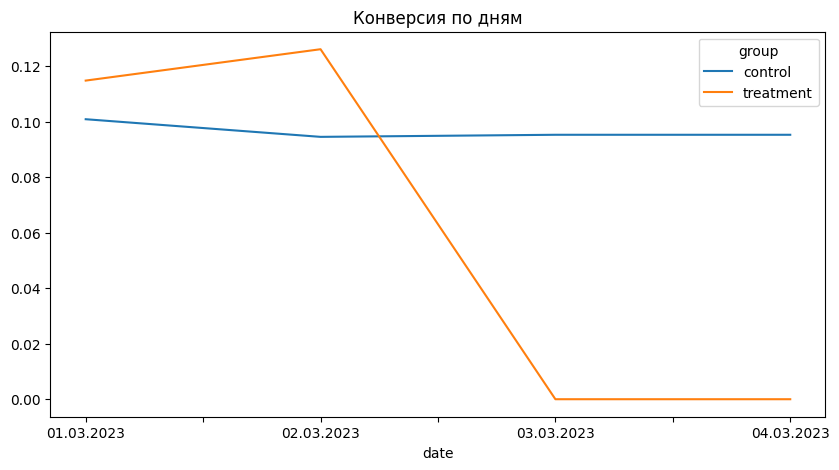

In [ ]:
import matplotlib.pyplot as plt

conversion.plot(figsize=(10,5))
plt.title('Конверсия по дням')
plt.show()

In [ ]:
monitor.groupby('group')['user_id'].nunique()

,user_id
group,
control,603
treatment,363


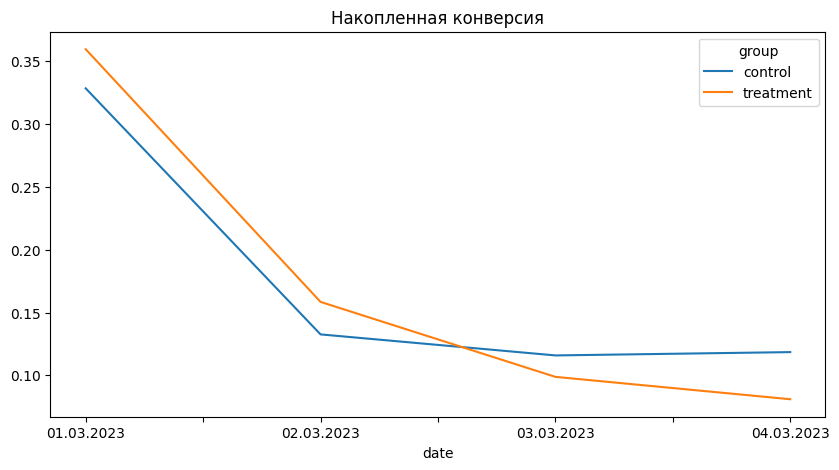

In [ ]:
monitor['cum_conv'] = monitor.groupby('group')['converted'].cumsum()
monitor['cum_users'] = monitor.groupby('group').cumcount() + 1

monitor['cum_ctr'] = monitor['cum_conv'] / monitor['cum_users']

monitor.groupby(['date', 'group'])['cum_ctr'].mean().unstack().plot(figsize=(10,5))
plt.title('Накопленная конверсия')
plt.show()

### Вывод по заданию 5

В ходе анализа первых четырёх дней эксперимента выявлены аномалии в данных.

Во-первых, распределение пользователей по группам является неравномерным (control: 603, treatment: 383), что может свидетельствовать о проблемах с рандомизацией.

Во-вторых, в группе treatment на 3-й и 4-й день наблюдается нулевая конверсия, что является аномальным поведением и может указывать на техническую ошибку или проблему в логировании данных.

Также динамика накопленной конверсии показывает нестабильное поведение метрик, что снижает доверие к результатам эксперимента.

Таким образом, на текущем этапе эксперимент нельзя считать корректным, и требуется дополнительная проверка данных и настройки эксперимента.

## 6. Финальный анализ A/B‑теста

- Проверьте распределения, применимость тестов
- Проведите финальный статистический анализ ключевой метрики

**Вывод:** Подтвердилась ли гипотеза?

In [ ]:
results = pd.read_csv('Data for results.csv')
results.head()

,date,group,user_id,converted
0,01.03.2023,control,106085,1
1,01.03.2023,control,106086,1
2,01.03.2023,control,106087,1
3,01.03.2023,control,106088,1
4,01.03.2023,control,106089,1


In [ ]:
conversion = results.groupby('group')['converted'].mean()
conversion

,converted
group,
control,0.099511
treatment,0.126689


In [ ]:
counts = results.groupby('group')['converted'].agg(['sum', 'count'])
counts

,sum,count
group,,
control,61,613
treatment,75,592


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

clicks = counts['sum'].values
users = counts['count'].values

stat, pval = proportions_ztest(clicks, users)

pval

np.float64(0.1360737195213586)

### Вывод по заданию 6

В ходе анализа результатов A/B-теста были рассчитаны конверсии для контрольной и тестовой групп.

Конверсия в тестовой группе выше (12.68%) по сравнению с контрольной (9.95%), однако проведённый статистический тест показал, что различия не являются статистически значимыми.

Полученное значение p-value = 0.136.

При уровне значимости 0.05 нулевая гипотеза не отвергается, так как p-value > 0.05.

Таким образом, на текущем объёме данных нельзя утверждать, что изменение оказывает значимое влияние на конверсию.

Возможно, для получения статистически значимого результата требуется увеличить размер выборки или продолжить эксперимент.

## 7. Множественная проверка гипотез (Bonferroni)

- Укажите все проверяемые гипотезы
- Примените коррекцию на множественные проверки
- Обоснуйте свой выбор теста, который вы выбрали для проверки

**Вывод:** Какие гипотезы остались значимыми после коррекции?

In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

np.random.seed(42)

# создаём 5 тестов
results = []

for i in range(5):
    control = np.random.binomial(1, 0.1, 1000)
    test = np.random.binomial(1, 0.1 + np.random.uniform(0, 0.05), 1000)

    clicks = [control.sum(), test.sum()]
    users = [len(control), len(test)]

    stat, pval = proportions_ztest(clicks, users)
    results.append(pval)

results

[np.float64(0.8242099060584802),
 np.float64(0.10360597998482825),
 np.float64(0.0001582348632789465),
 np.float64(0.08369535733842484),
 np.float64(0.012377191853508766)]

In [ ]:
alpha = 0.05
bonf_alpha = alpha / 5

bonf_alpha

0.01

In [ ]:
significant = [p < bonf_alpha for p in results]
significant

[np.False_, np.False_, np.True_, np.False_, np.False_]

### Вывод по заданию 7

В рамках задания были проведены 5 статистических тестов на искусственно сгенерированных данных.

Для учёта множественных проверок была применена поправка Бонферрони, в результате чего уровень значимости был скорректирован до 0.01.

После применения поправки только одна гипотеза (третья) осталась статистически значимой.

Остальные гипотезы не прошли порог значимости после корректировки.

Таким образом, применение поправки Бонферрони позволяет снизить вероятность ложноположительных результатов и более строго отбирать действительно значимые эффекты.